## Comparison of Static vs Dynamic (Physio) fMRI Data

This notebook visualizes the difference between the **Static GLM Betas** (from `SynBrain/prepare_nsddata_scale.py`) and the **Dynamic Physiological Trajectories** (from `simulate_hemodynamics.py`) for the *same* visual stimulus.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths to data
data_root = 'data/NSD/nsd/subj01'

stim_path = os.path.join(data_root, 'nsd_train_stim_sub1.npy')
static_fmri_path = os.path.join(data_root, 'nsd_train_fmri_scale_sub1.npy')
dynamic_physio_path = 'data/NSD/nsd/physio/nsd_train_physio_sub1.npy'

print(f"Checking files:")
print(f"Stimuli: {os.path.exists(stim_path)}")
print(f"Static fMRI: {os.path.exists(static_fmri_path)}")
print(f"Dynamic Physio: {os.path.exists(dynamic_physio_path)}")

In [4]:
def safe_load(path, name, use_mmap=True):
    try:
        if use_mmap:
            data = np.load(path, mmap_mode='r')
        else:
            data = np.load(path, allow_pickle=True)
        print(f"{name} loaded successfully. Shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Failed to load {name} with mmap={use_mmap}: {e}")
        if use_mmap:
            print(f"Retrying {name} without mmap (allow_pickle=True)...")
            return safe_load(path, name, use_mmap=False)
        return None

# Load data
# Stimuli is typically huge, so we prefer mmap. Others are smaller.
stim_data = safe_load(stim_path, "Stimuli", use_mmap=True)
static_fmri = safe_load(static_fmri_path, "Static fMRI", use_mmap=True)
dynamic_physio = safe_load(dynamic_physio_path, "Dynamic Physio", use_mmap=True)

Stimuli loaded successfully. Shape: (9000, 425, 425, 3)
Static fMRI loaded successfully. Shape: (9000, 3, 15724)
Failed to load Dynamic Physio with mmap=True: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.
Retrying Dynamic Physio without mmap (allow_pickle=True)...
Failed to load Dynamic Physio with mmap=False: Failed to interpret file 'data/NSD/nsd/physio/nsd_train_physio_sub1.npy' as a pickle


In [ ]:
def plot_comparison(idx, top_k=5):
    """
    Plots Image vs Static Betas vs Dynamic BOLD for a specific sample index.
    idx: Sample index
    top_k: Number of most active voxels to plot
    """
    
    if stim_data is None or static_fmri is None or dynamic_physio is None:
        print("Data missing, cannot plot.")
        return

    # 1. Get Image
    img = stim_data[idx]
    
    # 2. Get Static Data
    # Static shape: [N, 3, Voxels]. Mean over repetitions.
    static_activity = np.mean(static_fmri[idx], axis=0)
    
    # 3. Get Dynamic Data
    # Dynamic shape: [N, Time, Voxels, 4]
    
    # Identify top active voxels
    top_voxels = np.argsort(np.abs(static_activity))[-top_k:]
    
    # --- PLOTTING ---
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 2)
    
    # A. Image
    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.imshow(img)
    ax_img.set_title(f"Stimulus Image (Index {idx})")
    ax_img.axis('off')
    
    # B. Static Activity Distribution
    ax_static = fig.add_subplot(gs[0, 1])
    ax_static.hist(static_activity, bins=100, color='skyblue', log=True)
    ax_static.set_title("Static GLM Betas Distribution (All Voxels)")
    ax_static.set_xlabel("Beta Value")
    ax_static.set_ylabel("Count (Log Scale)")
    
    # C. Dynamic Trajectories
    ax_dyn = fig.add_subplot(gs[1, :])
    time_steps = np.arange(dynamic_physio.shape[1]) * 0.5 # Assuming dt=0.5s
    
    for v_idx in top_voxels:
        traj = dynamic_physio[idx, :, v_idx, 0] # s (signal)
        ax_dyn.plot(time_steps, traj, label=f'Voxel {v_idx} (Static={static_activity[v_idx]:.2f})')
    
    ax_dyn.set_title(f"Dynamic Physiological Response (State 's') for Top {top_k} Active Voxels")
    ax_dyn.set_xlabel("Time (s)")
    ax_dyn.set_ylabel("Signal Amplitude")
    ax_dyn.legend()
    
    # D. Full State Dynamics
    best_voxel = top_voxels[-1]
    ax_states = fig.add_subplot(gs[2, :])
    state_labels = ['s (Signal)', 'f (Inflow)', 'v (Volume)', 'q (dHb)']
    for i in range(4):
        ax_states.plot(time_steps, dynamic_physio[idx, :, best_voxel, i], label=state_labels[i])
        
    ax_states.set_title(f"Full Balloon-Windkessel States for Most Active Voxel ({best_voxel})")
    ax_states.set_xlabel("Time (s)")
    ax_states.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Run Visualization for Sample 0
plot_comparison(idx=0, top_k=5)

### Single-trial visualization: Subject 1, Session 1
This cell loads **NSD subject 1, session 1**, picks one trial, and visualizes the corresponding **stimulus image** together with its **GLM beta vector** (using the same `nsdgeneral` mask and scaling as `prepare_nsddata_scale.py`).

Subject 1, Session 1, Trial 0
NSD image index: 46002
Mask exists: True
Betas file exists: True
Number of voxels in nsdgeneral mask: 15724
Single-trial beta volume shape: (81, 104, 83)
Beta vector shape after masking: (15724,)


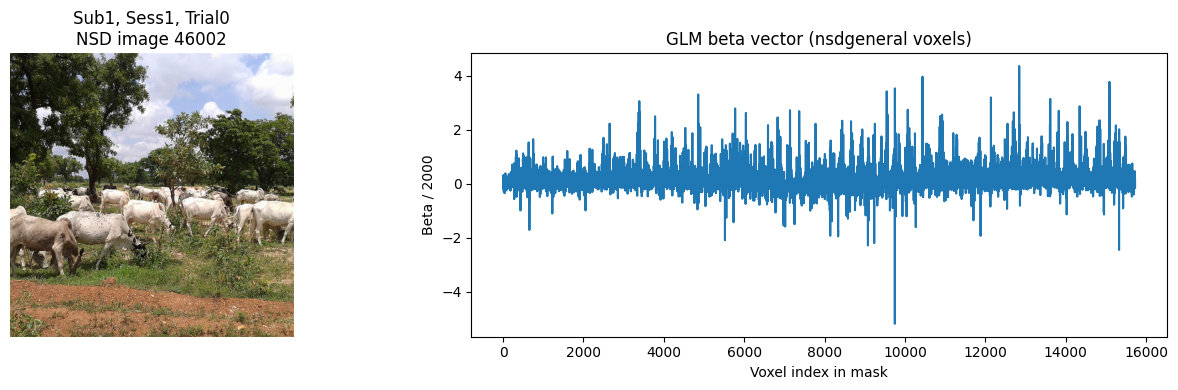

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import scipy.io as spio
import h5py

sub = 1                 # subject 1
session_idx = 0         # session 1 (0-based index)
trial_idx_in_sess = 0   # choose trial 0 within session 1

data_root = 'data/NSD'  # root of NSD data

expdesign_path = os.path.join(data_root, 'nsddata/experiments/nsd/nsd_expdesign.mat')
design = spio.loadmat(expdesign_path, squeeze_me=True, struct_as_record=False)
subjectim = design['subjectim']           # [subjects, images]
masterordering = design['masterordering'] # [trials]

trial_abs = session_idx * 750 + trial_idx_in_sess
nsd_image_id = int(subjectim[sub - 1, masterordering[trial_abs] - 1] - 1)

print(f"Subject {sub}, Session {session_idx+1}, Trial {trial_idx_in_sess}")
print(f"NSD image index: {nsd_image_id}")

stim_file_path = os.path.join(data_root, 'nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5')
with h5py.File(stim_file_path, 'r') as f_stim:
    img = f_stim['imgBrick'][nsd_image_id]   # shape: [H, W, 3]

roi_dir = os.path.join(data_root, f'nsddata/ppdata/subj{sub:02d}/func1pt8mm/roi')
betas_dir = os.path.join(data_root, f'nsddata_betas/ppdata/subj{sub:02d}/func1pt8mm/betas_fithrf_GLMdenoise_RR')

mask_path = os.path.join(roi_dir, 'nsdgeneral.nii.gz')
beta_path = os.path.join(betas_dir, 'betas_session01.nii.gz')

print(f"Mask exists: {os.path.exists(mask_path)}")
print(f"Betas file exists: {os.path.exists(beta_path)}")

mask = nib.load(mask_path).get_fdata()
mask_bool = mask > 0
num_voxels = int(mask_bool.sum())
print(f"Number of voxels in nsdgeneral mask: {num_voxels}")

beta_img = nib.load(beta_path)
beta_data = beta_img.dataobj              # lazy proxy, not full 4D load yet

# Take just one timepoint (trial) and apply mask
single_trial_3d = np.asanyarray(beta_data[..., trial_idx_in_sess], dtype=np.float32)  # [X, Y, Z]
beta_vec = single_trial_3d[mask_bool] / 2000.0   # same scaling as prepare_nsddata_scale.py

print(f"Single-trial beta volume shape: {single_trial_3d.shape}")
print(f"Beta vector shape after masking: {beta_vec.shape}")

# --- Visualization: image + beta vector ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# A. Stimulus image
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'Sub{sub}, Sess{session_idx+1}, Trial{trial_idx_in_sess}\nNSD image {nsd_image_id}')

# B. Beta vector (1D over masked voxels)
axes[1].plot(beta_vec)
axes[1].set_title('GLM beta vector (nsdgeneral voxels)')
axes[1].set_xlabel('Voxel index in mask')
axes[1].set_ylabel('Beta / 2000')

plt.tight_layout()
plt.show()

In [3]:
masterordering.shape

(30000,)